In [1]:
# ===============================================
# 1) Dataset Setup And Download
# ===============================================

import os
import zipfile

DATA_DIR = "/content/traffic-signs-data/"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

if not os.path.exists(os.path.join(DATA_DIR, "train.p")):
    print("Downloading dataset...")
    !wget -q https://d17h27t6h515a5.cloudfront.net/topher/2017/February/5898cd6f_traffic-signs-data/traffic-signs-data.zip -P {DATA_DIR}

    print("Extracting...")
    with zipfile.ZipFile(os.path.join(DATA_DIR, "traffic-signs-data.zip"), "r") as zf:
        zf.extractall(DATA_DIR)
    print("Extraction complete.")
else:
    print("Dataset already exists.")

if not os.path.exists(os.path.join(DATA_DIR, "signnames.csv")):
    print("Downloading labels...")
    !wget -q https://raw.githubusercontent.com/AvivSham/German-Traffic-Signs-Classification/master/signnames.csv -P {DATA_DIR}
    print("Labels downloaded.")
else:
    print("Labels already exist.")

print("\nSetup complete. Files:")
!ls {DATA_DIR}

Extracting...
Extraction complete.
Labels downloaded.

Setup complete. Files:
signnames.csv  test.p  traffic-signs-data.zip  train.p	valid.p


In [2]:
# ===============================================
# 2) Import Libraries And Configuration
# ===============================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

SEED = 50
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

DATA_PATH = "/content/traffic-signs-data/"
MODEL_PATH = DATA_PATH + "saved_model.keras"
NUM_CLASSES = 43
BATCH_SIZE = 64
EPOCHS = 30

TensorFlow version: 2.20.0


In [3]:
# ===============================================
# 3) Load Dataset And Class Labels
# ===============================================

print("Loading data...")

with open(DATA_PATH + "train.p", "rb") as f:
    train = pickle.load(f)

with open(DATA_PATH + "valid.p", "rb") as f:
    valid = pickle.load(f)

with open(DATA_PATH + "test.p", "rb") as f:
    test = pickle.load(f)

sign_names = pd.read_csv(DATA_PATH + "signnames.csv")
label_map = dict(zip(sign_names["ClassId"], sign_names["SignName"]))

X_train, y_train = train["features"], train["labels"]
X_valid, y_valid = valid["features"], valid["labels"]
X_test, y_test = test["features"], test["labels"]

print(f"Train: {X_train.shape}")
print(f"Valid: {X_valid.shape}")
print(f"Test:  {X_test.shape}")

Loading data...
Train: (34799, 32, 32, 3)
Valid: (4410, 32, 32, 3)
Test:  (12630, 32, 32, 3)


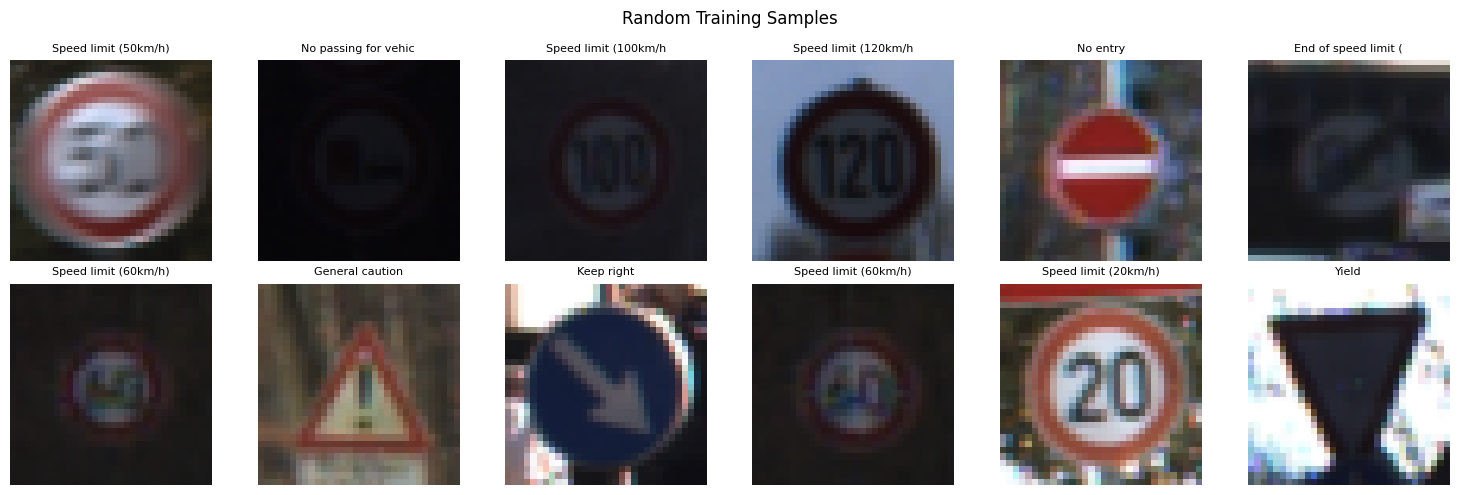

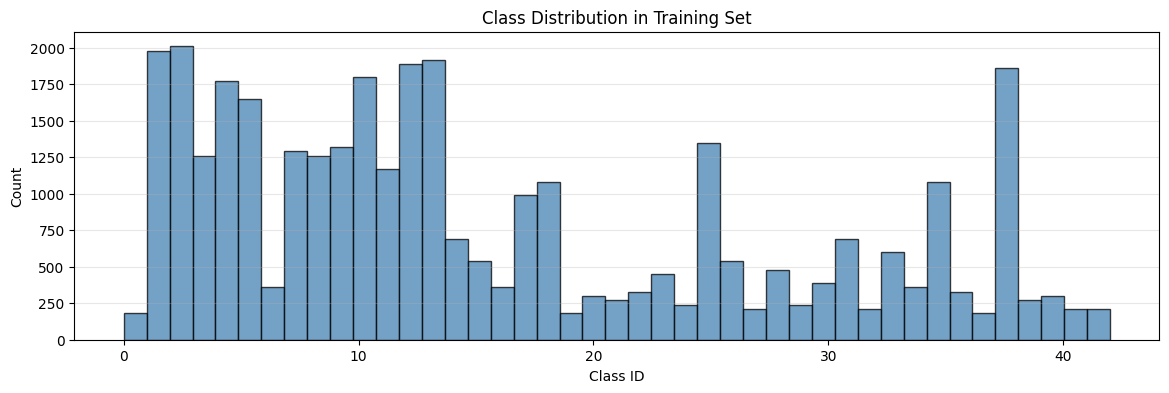

In [4]:
# ===============================================
# 4) Initial Data Visualization
# ===============================================

_, axes = plt.subplots(2, 6, figsize=(15, 5))

for i in range(12):
    idx = random.randint(0, len(X_train) - 1)
    ax = axes[i // 6][i % 6]
    ax.imshow(X_train[idx])
    ax.set_title(label_map[y_train[idx]][:20], fontsize=8)
    ax.axis("off")

plt.suptitle("Random Training Samples")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.hist(y_train, bins=NUM_CLASSES, edgecolor="black", alpha=0.75, color="steelblue")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.title("Class Distribution in Training Set")
plt.grid(axis="y", alpha=0.3)
plt.show()

Preprocessing images...


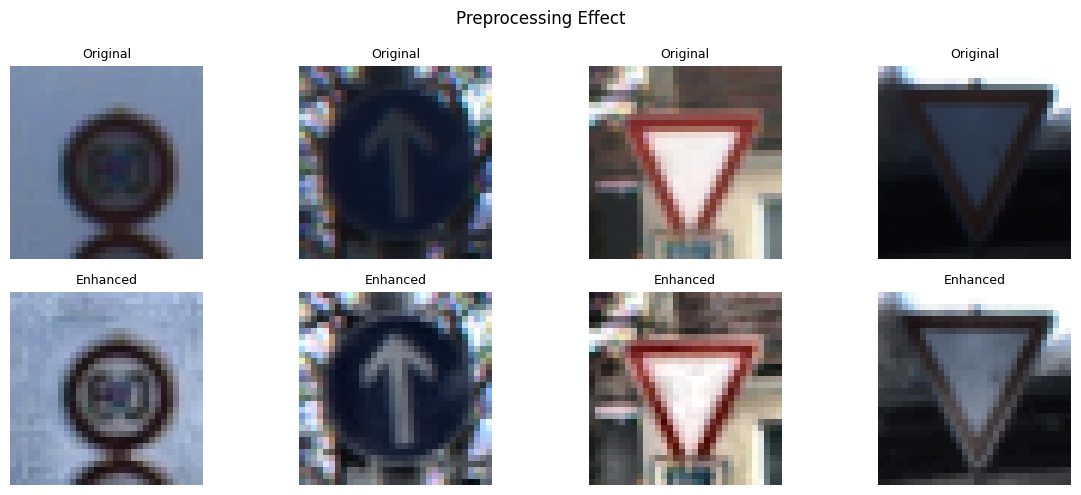

Input shape: (32, 32, 3)


In [5]:
# ===============================================
# 5) Image Preprocessing
# ===============================================

def preprocess_images(images):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    output = []

    for img in images:
        yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
        yuv[:, :, 0] = clahe.apply(yuv[:, :, 0])
        img_enhanced = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)
        output.append(img_enhanced)

    return np.array(output, dtype=np.float32) / 255.0

X_train, y_train = shuffle(X_train, y_train, random_state=SEED)

print("Preprocessing images...")

X_train_p = preprocess_images(X_train)
X_valid_p = preprocess_images(X_valid)
X_test_p = preprocess_images(X_test)

_, axes = plt.subplots(2, 4, figsize=(12, 5))
sample_indices = [random.randint(0, len(X_train) - 1) for _ in range(4)]

for i, idx in enumerate(sample_indices):
    axes[0, i].imshow(X_train[idx])
    axes[0, i].set_title("Original", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(X_train_p[idx])
    axes[1, i].set_title("Enhanced", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Preprocessing Effect")
plt.tight_layout()
plt.show()

print(f"Input shape: {X_train_p[0].shape}")

In [6]:
# ===============================================
# 6) CNN Model Architecture
# ===============================================

def create_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)

model = create_model(X_train_p[0].shape, NUM_CLASSES)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,02

 Total params: 184,779 (721.79 KB)

 Trainable params: 184,139 (719.29 KB)

 Non-trainable params: 640 (2.50 KB)

In [7]:
# ===============================================
# 7) Model Compilation And Callbacks
# ===============================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

In [8]:
# ===============================================
# 8) Model Training And Saving
# ===============================================

print("Starting training...")

history = model.fit(
    X_train_p, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_valid_p, y_valid),
    callbacks=callbacks,
    verbose=1
)

model.save(MODEL_PATH)
print(f"\nModel saved to {MODEL_PATH}")

try:
    from google.colab import files
    print("Downloading model...")
    files.download(MODEL_PATH)
except ImportError:
    print("Not running in Google Colab. Model is saved locally.")

Starting training...
Epoch 1/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.4430 - loss: 1.8827 - val_accuracy: 0.5812 - val_loss: 1.4341 - learning_rate: 0.0010
Epoch 2/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8360 - loss: 0.5261 - val_accuracy: 0.8907 - val_loss: 0.3710 - learning_rate: 0.0010
Epoch 3/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9366 - loss: 0.2091 - val_accuracy: 0.9077 - val_loss: 0.3419 - learning_rate: 0.0010
Epoch 4/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9658 - loss: 0.1141 - val_accuracy: 0.9023 - val_loss: 0.3091 - learning_rate: 0.0010
Epoch 5/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9769 - loss: 0.0796 - val_accuracy: 0.9551 - val_loss: 0.1763 - learning_rate: 0.0010
Epoch 6/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9802 - loss: 0.0636 - val_accuracy: 0.8989 - val_loss: 0.3310 - learning_rate: 0.0010
Epoch 7/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

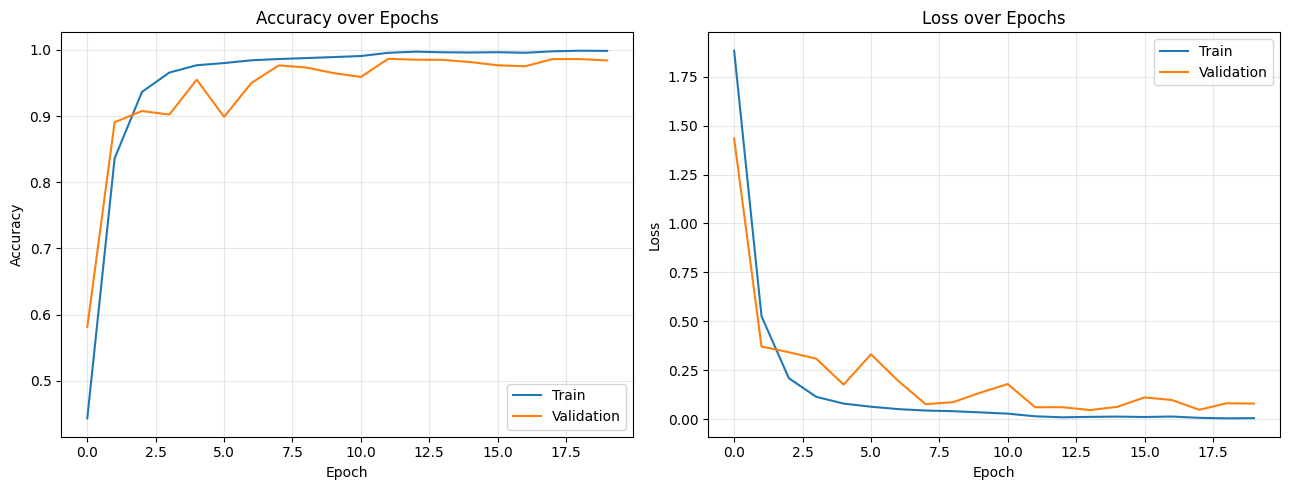

In [9]:
# ===============================================
# 9) Training Curves Visualization
# ===============================================

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(history.history["accuracy"], label="Train")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history["loss"], label="Train")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Loss over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ===============================================
# 10) Test Evaluation And Classification Report
# ===============================================

print("Evaluating on test set...")

test_loss, test_acc = model.evaluate(X_test_p, y_test, verbose=0)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test_p, verbose=0), axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Evaluating on test set...
Test Accuracy: 0.9716
Test Loss: 0.1232

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       0.99      1.00      0.99       720
           2       0.99      1.00      0.99       750
           3       0.97      0.96      0.97       450
           4       1.00      0.98      0.99       660
           5       0.95      0.99      0.97       630
           6       1.00      0.85      0.92       150
           7       0.97      1.00      0.98       450
           8       1.00      0.95      0.97       450
           9       1.00      0.99      1.00       480
          10       1.00      1.00      1.00       660
          11       0.98      0.99      0.98       420
          12       1.00      0.98      0.99       690
          13       0.97      1.00      0.98       720
          14       0.98      1.00      0.99       270
          15       1.00      1.00      1.00 

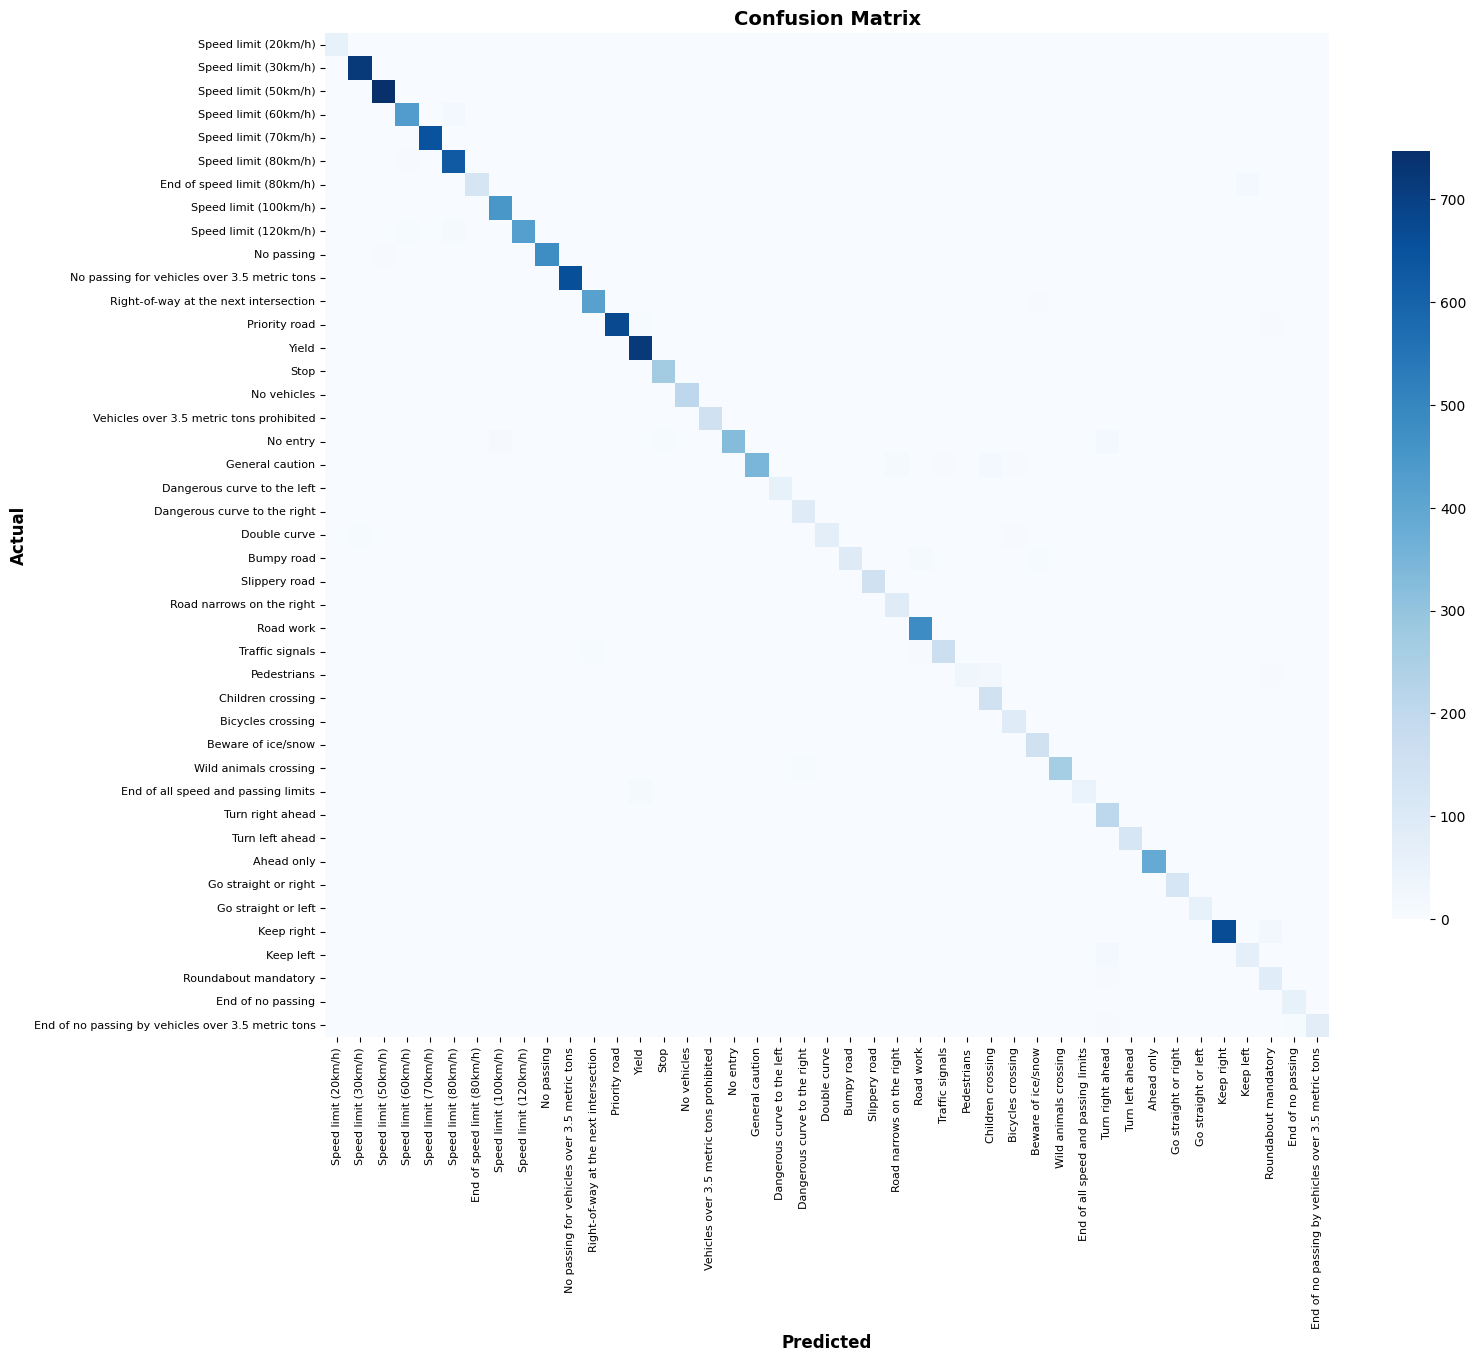

In [11]:
# ===============================================
# 11) Confusion Matrix Visualization
# ===============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    cmap="Blues",
    square=True,
    xticklabels=list(label_map.values()),
    yticklabels=list(label_map.values()),
    annot=False,
    cbar_kws={"shrink": 0.7}
)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.xlabel("Predicted", fontsize=12, fontweight="bold")
plt.ylabel("Actual", fontsize=12, fontweight="bold")
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

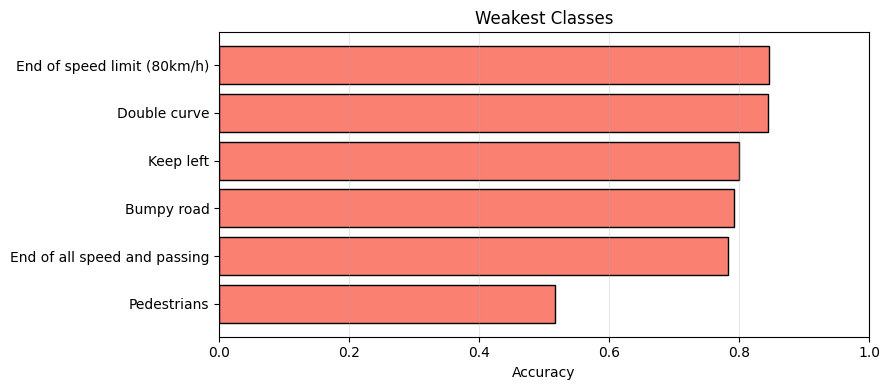

In [12]:
# ===============================================
# 12) Weakest Class Analysis
# ===============================================

per_class = cm.diagonal() / cm.sum(axis=1)

worst = np.argsort(per_class)[:6]

plt.figure(figsize=(9, 4))
plt.barh(
    [label_map[i][:28] for i in worst],
    per_class[worst],
    color="salmon",
    edgecolor="black"
)
plt.xlabel("Accuracy")
plt.title("Weakest Classes")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

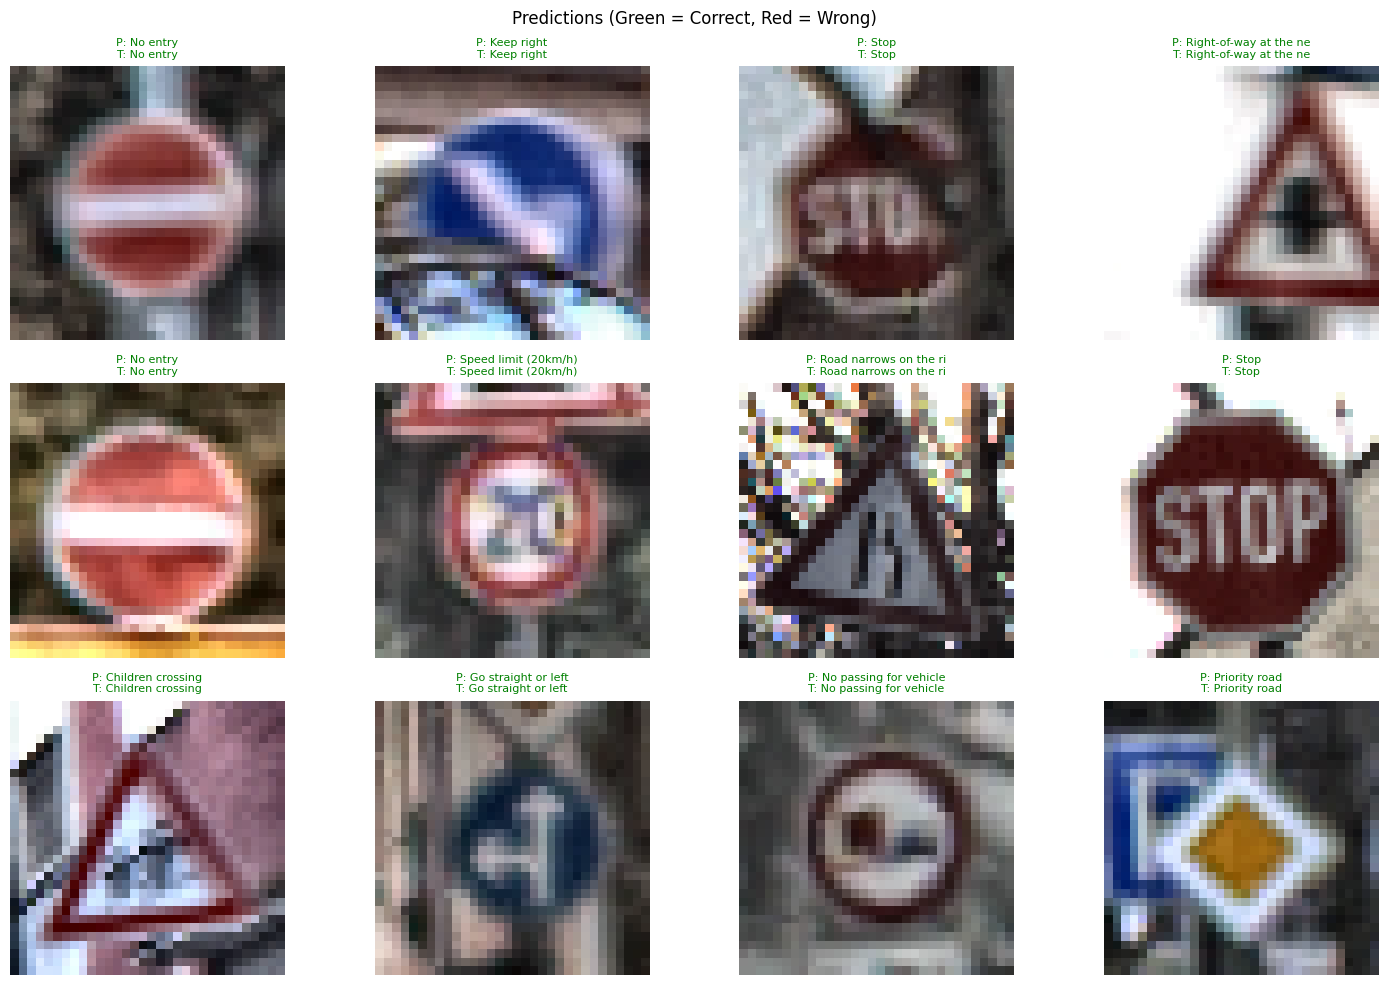

In [13]:
# ===============================================
# 13) Random Test Predictions
# ===============================================

plt.figure(figsize=(15, 10))

for i in range(12):
    idx = random.randint(0, len(X_test_p) - 1)
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test_p[idx])

    p = y_pred[idx]
    t = y_test[idx]

    color = "green" if p == t else "red"
    plt.title(
        f"P: {label_map[p][:22]}\nT: {label_map[t][:22]}",
        fontsize=8,
        color=color
    )
    plt.axis("off")

plt.suptitle("Predictions (Green = Correct, Red = Wrong)")
plt.tight_layout()
plt.show()

In [14]:
# ===============================================
# 14) Final Training Summary
# ===============================================

best_epoch_idx = np.argmin(history.history["val_loss"])
best_epoch = best_epoch_idx + 1

best_val_loss = history.history["val_loss"][best_epoch_idx]
best_val_acc_at_best = history.history["val_accuracy"][best_epoch_idx]

epochs_trained = len(history.history["loss"])

print("=" * 55)
print("Final Summary")
print("=" * 55)
print(f"Dataset                    : German Traffic Sign Recognition Benchmark")
print(f"Classes                    : {NUM_CLASSES}")
print(f"Train / Val / Test Samples : {len(X_train_p):,} / {len(X_valid_p):,} / {len(X_test_p):,}")
print("-" * 55)
print(f"Epochs Requested           : {EPOCHS}")
print(f"Epochs Trained             : {epochs_trained}")
print(f"Best Model Criterion       : Minimum Validation Loss")
print(f"Best Validation Epoch      : {best_epoch}")
print(f"Best Validation Loss       : {best_val_loss:.4f}")
print(f"Validation Accuracy @ Best : {best_val_acc_at_best:.4f}")
print("-" * 55)
print(f"Test Loss                  : {test_loss:.4f}")
print(f"Test Accuracy              : {test_acc:.4f}")
print(f"Total Parameters           : {model.count_params():,}")
print("-" * 55)
print("Note: Because restore_best_weights=True was used,")
print("the final test result is based on the best")
print(f"validation-loss model from epoch {best_epoch}, not the last epoch.")
print("=" * 55)

Final Summary
Dataset                    : German Traffic Sign Recognition Benchmark
Classes                    : 43
Train / Val / Test Samples : 34,799 / 4,410 / 12,630
-------------------------------------------------------
Epochs Requested           : 30
Epochs Trained             : 20
Best Model Criterion       : Minimum Validation Loss
Best Validation Epoch      : 14
Best Validation Loss       : 0.0464
Validation Accuracy @ Best : 0.9850
-------------------------------------------------------
Test Loss                  : 0.1232
Test Accuracy              : 0.9716
Total Parameters           : 184,779
-------------------------------------------------------
Note: Because restore_best_weights=True was used,
the final test result is based on the best
validation-loss model from epoch 14, not the last epoch.
